# I. Introduction

Dự án này tập trung vào việc phát triển một mô hình học máy để dự đoán nguy cơ mắc bệnh tiểu đường dựa trên các yếu tố nguy cơ khác nhau. Sử dụng thuật toán Support Vector Machine (SVM), mô hình phân tích dữ liệu từ nhiều khía cạnh như:

- Thông tin nhân khẩu học (tuổi, giới tính)
- Các chỉ số sức khỏe (BMI, mức đường huyết, HbA1c)
- Tiền sử bệnh lý (huyết áp cao, bệnh tim)
- Thói quen sinh hoạt (lịch sử hút thuốc)

Mục tiêu chính của dự án là:
1. Xây dựng mô hình có độ chính xác cao trong việc dự đoán nguy cơ tiểu đường
2. Phân tích các yếu tố ảnh hưởng đến nguy cơ mắc bệnh
3. Tạo công cụ hỗ trợ cho việc sàng lọc sớm bệnh tiểu đường

Dữ liệu được thu thập từ nguồn diabetes_prediction_dataset.csv, bao gồm thông tin của nhiều bệnh nhân với các đặc điểm khác nhau.

### 1. Import các thư viện cần thiết để chạy mô hình

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. Input data

In [124]:
data = pd.read_csv('diabetes_prediction_dataset.csv')
data_info = {
    "shape": data.shape,
    "columns": data.columns.tolist(),
    "missing_values": data.isnull().sum().to_dict(),
    "head": data.head().to_dict()
}

data_info

{'shape': (100000, 9),
 'columns': ['gender',
  'age',
  'hypertension',
  'heart_disease',
  'smoking_history',
  'bmi',
  'HbA1c_level',
  'blood_glucose_level',
  'diabetes'],
 'missing_values': {'gender': 0,
  'age': 0,
  'hypertension': 0,
  'heart_disease': 0,
  'smoking_history': 0,
  'bmi': 0,
  'HbA1c_level': 0,
  'blood_glucose_level': 0,
  'diabetes': 0},
 'head': {'gender': {0: 'Female',
   1: 'Female',
   2: 'Male',
   3: 'Female',
   4: 'Male'},
  'age': {0: 80.0, 1: 54.0, 2: 28.0, 3: 36.0, 4: 76.0},
  'hypertension': {0: 0, 1: 0, 2: 0, 3: 0, 4: 1},
  'heart_disease': {0: 1, 1: 0, 2: 0, 3: 0, 4: 1},
  'smoking_history': {0: 'never',
   1: 'No Info',
   2: 'never',
   3: 'current',
   4: 'current'},
  'bmi': {0: 25.19, 1: 27.32, 2: 27.32, 3: 23.45, 4: 20.14},
  'HbA1c_level': {0: 6.6, 1: 6.6, 2: 5.7, 3: 5.0, 4: 4.8},
  'blood_glucose_level': {0: 140, 1: 80, 2: 158, 3: 155, 4: 155},
  'diabetes': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}}}

# II. EXPLORATORY DATA ANALYSIS

## Chất lượng dữ liệu

### 1. Xử lý trùng lặp

In [125]:
## Xử lý trùng lặp
duplicate_rows_data = data[data.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (3854, 9)


In [126]:
data = data.drop_duplicates()

### 2. Uniqueness

In [98]:

## Lặp qua từng cột và đếm số lượng giá trị khác biệt
for column in data.columns:
    num_distinct_values = len(data[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

age: 102 distinct values
hypertension: 2 distinct values
heart_disease: 2 distinct values
bmi: 4247 distinct values
HbA1c_level: 18 distinct values
blood_glucose_level: 18 distinct values
diabetes: 2 distinct values
gender_Female: 2 distinct values
gender_Male: 2 distinct values
gender_Other: 2 distinct values
smoking_history_No Info: 2 distinct values
smoking_history_current: 2 distinct values
smoking_history_ever: 2 distinct values
smoking_history_former: 2 distinct values
smoking_history_never: 2 distinct values
smoking_history_not current: 2 distinct values


### 3. Giá trị còn thiếu

In [127]:

## Kiếm tra các giá trị còn thiếu trong dữ liệu
print(data.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [128]:

### Loại bỏ giá trị không cần thiết[[0,00195%]
data = data[data['gender'] != 'Other']

### 4. Mô tả dữ liệu

In [129]:
data.describe().style.format("{:.2f}")

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00
mean,41.80,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


## Phân tích đơn biến

### 1.  Histogram for age

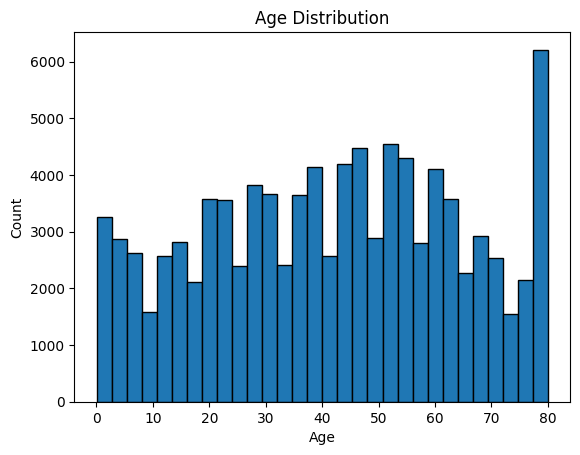

In [130]:
plt.hist(data['age'], bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### 2. Biểu đồ so sánh giữa 2 giới tính

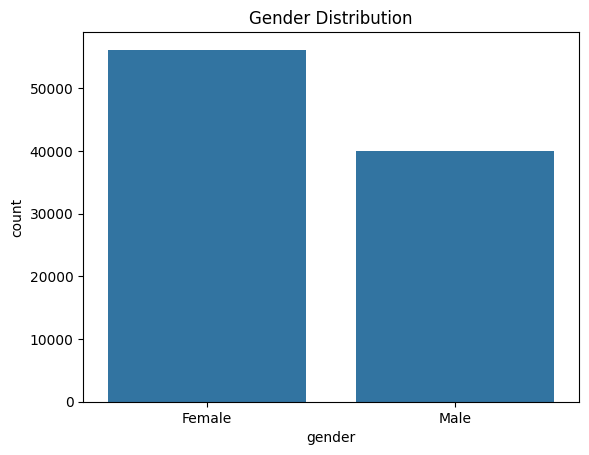

In [131]:
sns.countplot(x='gender', data=data)
plt.title('Gender Distribution')
plt.show()

### 3. Sơ đồ phân phối chỉ số BMI

C:\Users\ACER\AppData\Local\Temp\ipykernel_14680\2475181124.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['bmi'], bins=30)


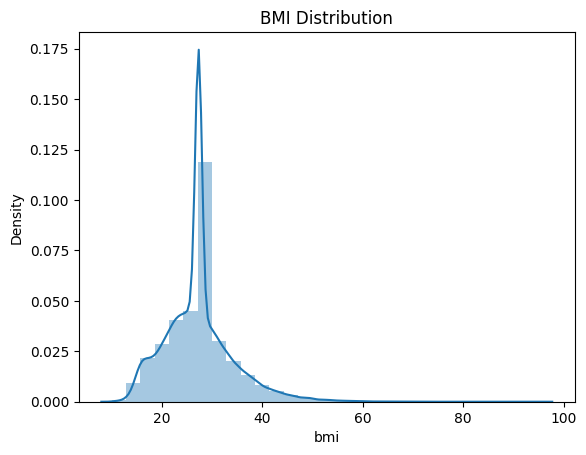

In [132]:
sns.distplot(data['bmi'], bins=30)
plt.title('BMI Distribution')
plt.show()

### 4. Biểu đồ đếm cho các biến nhị phân

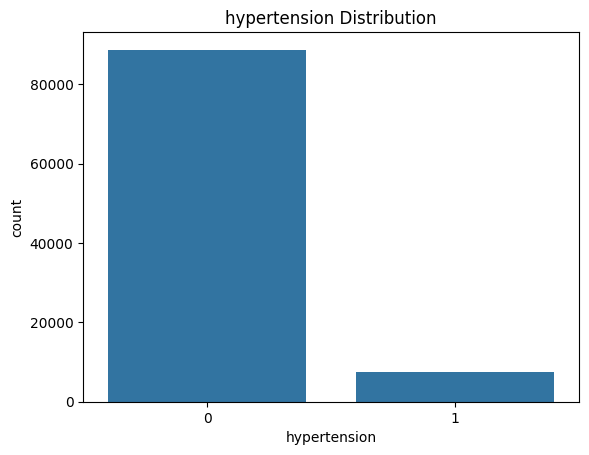

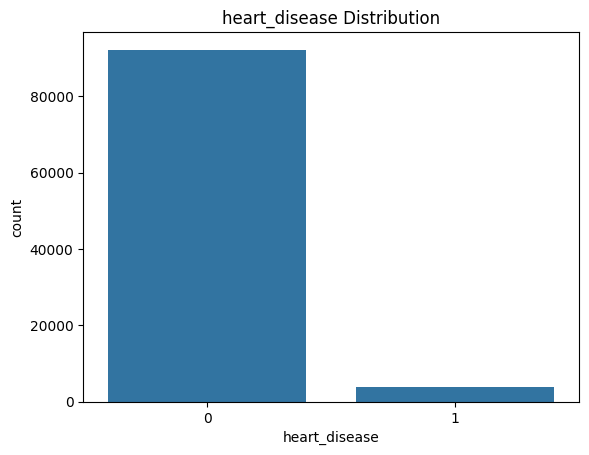

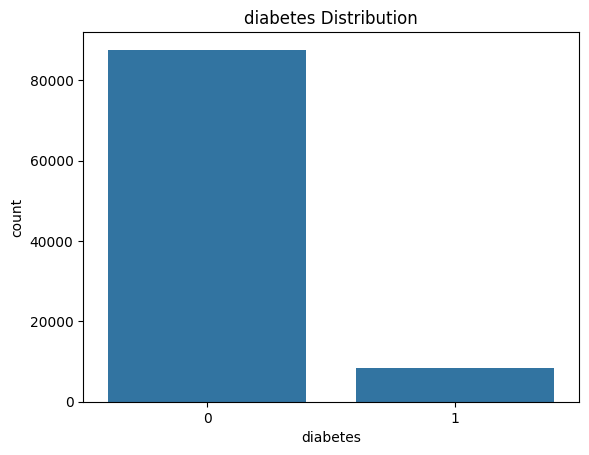

In [133]:
for col in ['hypertension', 'heart_disease', 'diabetes']:
    sns.countplot(x=col, data=data)
    plt.title(f'{col} Distribution')
    plt.show()

### 5. Biểu đồ đếm tiền sử hút thuốc

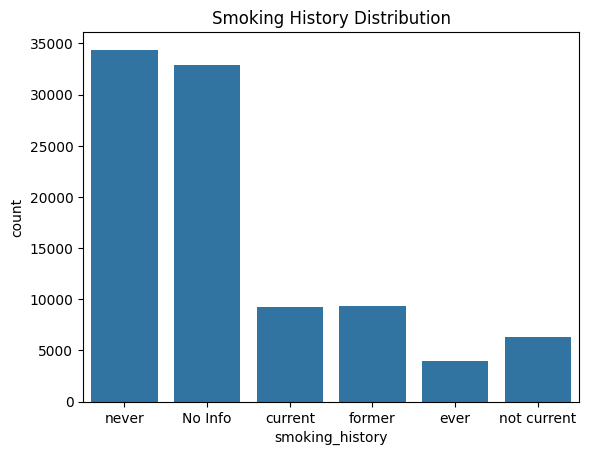

In [134]:
sns.countplot(x='smoking_history', data=data)
plt.title('Smoking History Distribution')
plt.show()

## Phân tích 2 biến

### 1. Biểu đồ hộp BMI và phân loại bệnh tiểu đường

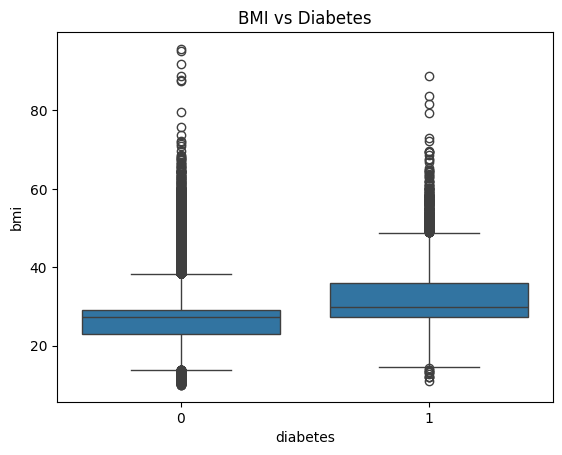

In [135]:
sns.boxplot(x='diabetes', y='bmi', data=data)
plt.title('BMI vs Diabetes')
plt.show()

### 2. Biểu đồ hộp Phân loại Tuổi tác so với Bệnh tiểu đường

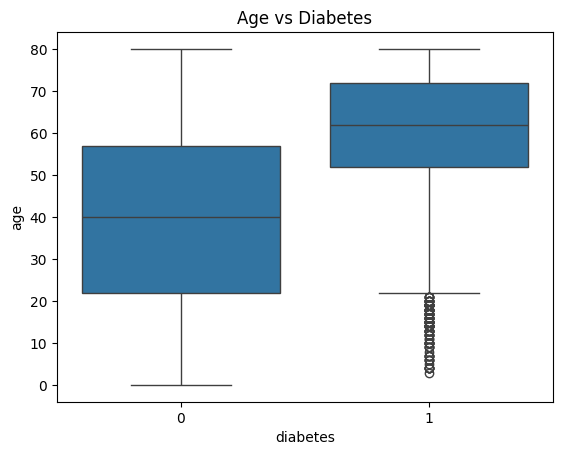

In [136]:
sns.boxplot(x='diabetes', y='age', data=data)
plt.title('Age vs Diabetes')
plt.show()

### 3. Biểu đồ đếm giới tính so với bệnh tiểu đường

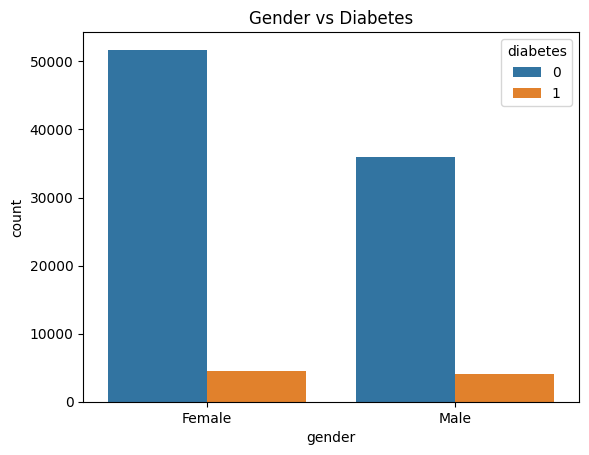

In [137]:
sns.countplot(x='gender', hue='diabetes', data=data)
plt.title('Gender vs Diabetes')
plt.show()

## Phân tích đa biến

## 1. Biểu đồ phân tán Tuổi so với BMI được tô màu theo phân loại bệnh tiểu đường

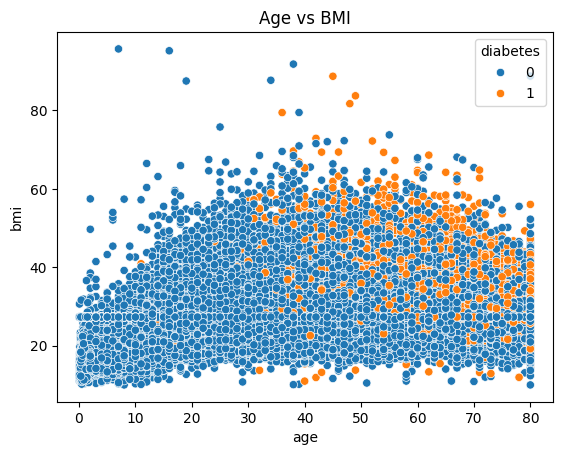

In [138]:
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=data)
plt.title('Age vs BMI')
plt.show()

## 2. Biểu đồ violin về BMI và phân loại bệnh tiểu đường chia theo giới tính

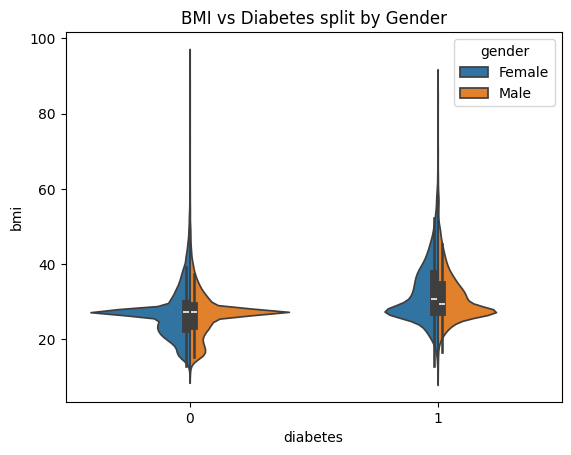

In [139]:
sns.violinplot(x='diabetes', y='bmi', hue='gender', split=True, data=data)
plt.title('BMI vs Diabetes split by Gender')
plt.show()

### 3. Tương tác giữa giới tính, BMI và bệnh tiểu đường

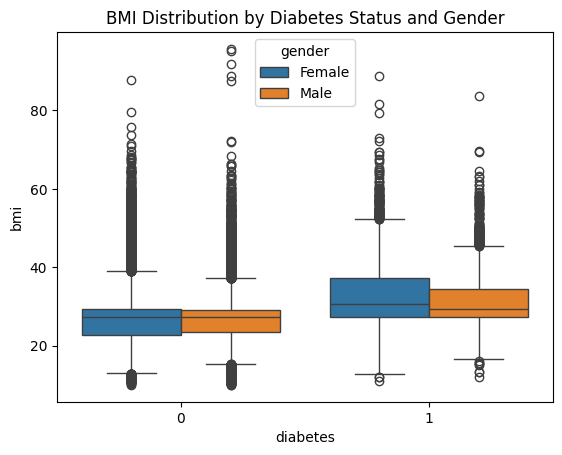

In [140]:
sns.boxplot(x='diabetes', y='bmi', hue='gender', data=data)
plt.title('BMI Distribution by Diabetes Status and Gender')
plt.show()

### 4. Tương tác giữa giới tính, tuổi tác và bệnh tiểu đường

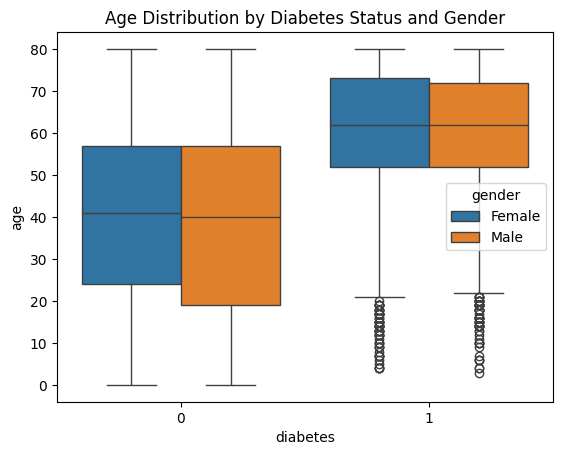

In [141]:
sns.boxplot(x='diabetes', y='age', hue='gender', data=data)
plt.title('Age Distribution by Diabetes Status and Gender')
plt.show()

# III. Tương quan

### 1. Chuẩn bị dữ liệu

In [146]:
# Định nghĩa một hàm để ánh xạ (chuyển đổi) các nhóm hút thuốc hiện có sang nhóm mới
def recategorize_smoking(smoking_status):
    if smoking_status in ['never', 'No Info']:
        return 'non-smoker'  # không hút thuốc
    elif smoking_status == 'current':
        return 'current'      # đang hút thuốc
    elif smoking_status in ['ever', 'former', 'not current']:
        return 'past_smoker'  # đã từng hút thuốc

# Áp dụng hàm trên cho cột 'smoking_history'
data['smoking_history'] = data['smoking_history'].apply(recategorize_smoking)

# Kiểm tra lại số lượng từng nhóm sau khi phân loại lại
print(data['smoking_history'].value_counts())


smoking_history
current    9197
Name: count, dtype: int64


### 2. Encoding

In [147]:
# Tạo bản sao dữ liệu
data_encoded = data.copy()

# Kiểm tra các cột hiện có
print("Columns before encoding:", data_encoded.columns.tolist())

# Thực hiện encoding
data_encoded = perform_one_hot_encoding(data_encoded, 'gender')
data_encoded = perform_one_hot_encoding(data_encoded, 'smoking_history')

# Kiểm tra kết quả
print("\nColumns after encoding:", data_encoded.columns.tolist())

Columns before encoding: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Columns after encoding: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male', 'smoking_history_current']


### 3. Ma trận tương quan

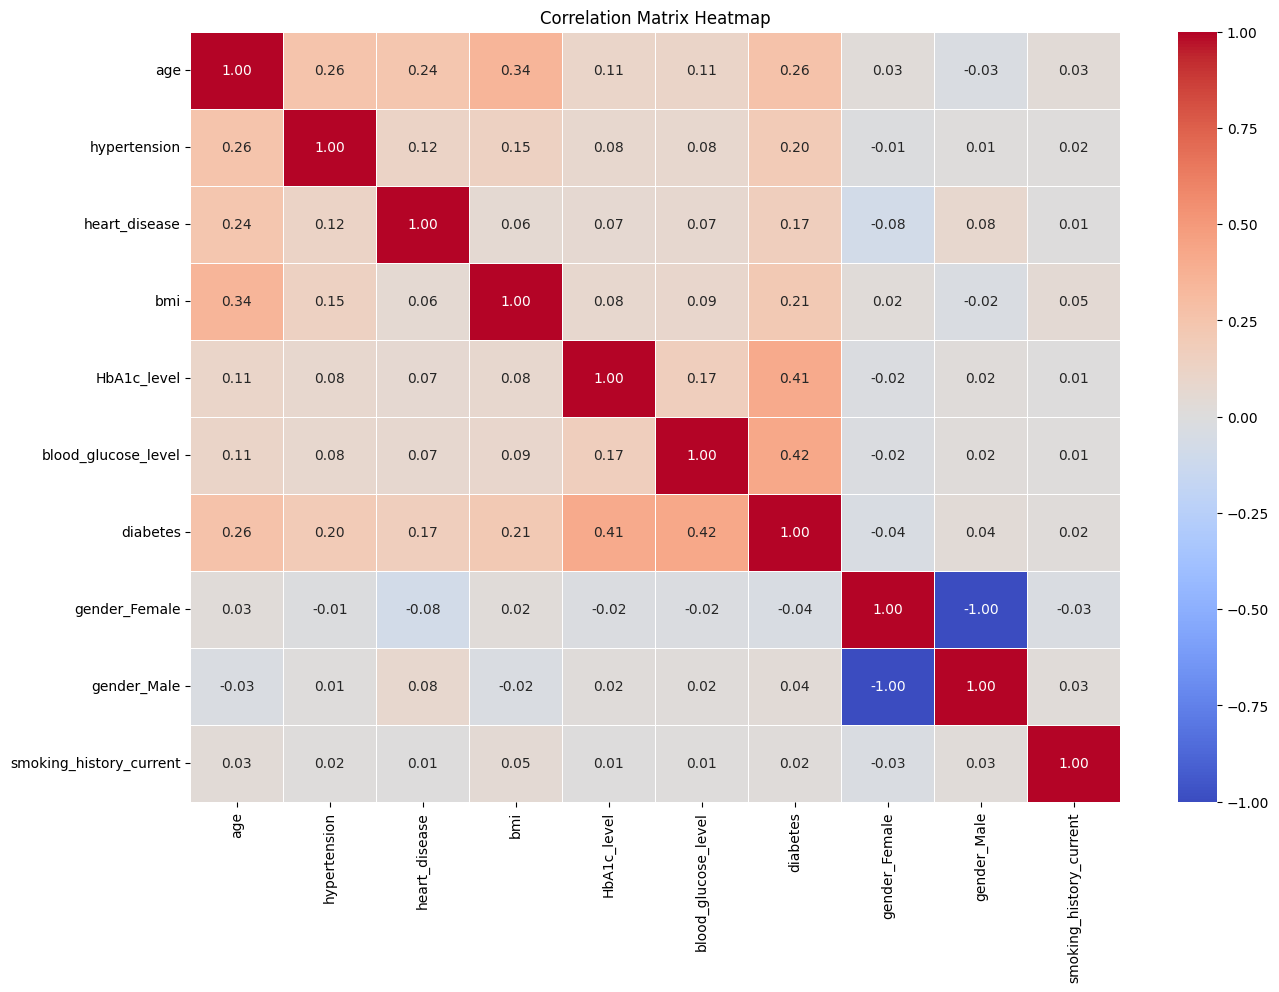

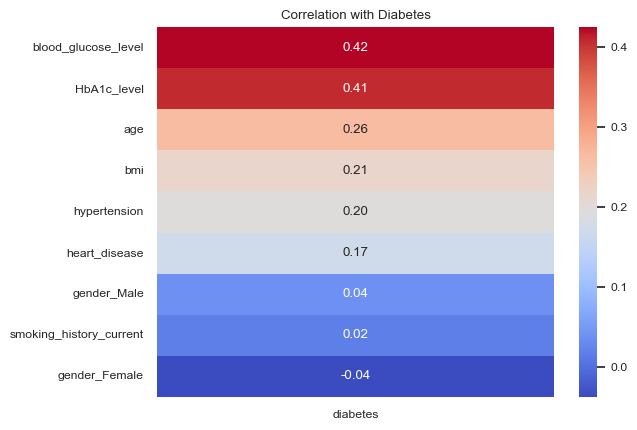

In [149]:
# Compute the correlation matrix
correlation_matrix = data_encoded.corr()

# Graph I.
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

# Graph II
# Create a heatmap of the correlations with the target column
corr = data_encoded.corr()
target_corr = corr['diabetes'].drop('diabetes')

# Sort correlation values in descending order
target_corr_sorted = target_corr.sort_values(ascending=False)

sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

# IV. Phân tích dự đoán

## Mất cân bằng lớp

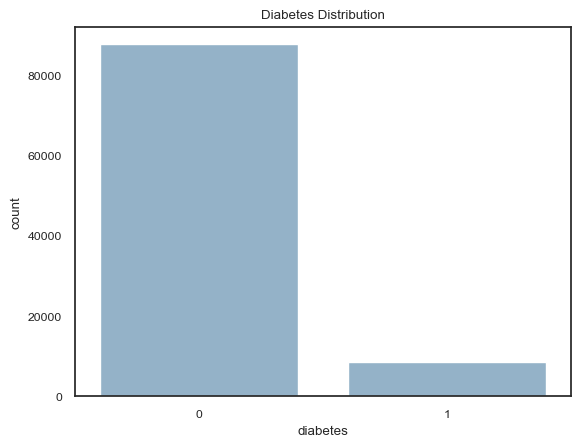

In [153]:
sns.countplot(x='diabetes', data=data)
plt.title('Diabetes Distribution')
plt.show()

In [154]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

## Tiền xử lý

Tiền xử lý là một bước rất quan trọng trước khi huấn luyện mô hình.
Trong trường hợp này, các đặc trưng dạng số (numerical features) được chuẩn hóa (standardized) — tức là loại bỏ giá trị trung bình và chia tỷ lệ sao cho có phương sai bằng 1.
Các đặc trưng dạng phân loại (categorical features) thì được mã hóa one-hot.

Việc chuẩn hóa không bắt buộc đối với tất cả các mô hình, nhưng nhìn chung là một thực hành tốt giúp mô hình học ổn định và hiệu quả hơn.
Còn mã hóa one-hot là bắt buộc để các biến phân loại có thể được mô hình học máy hiểu đúng cách.

## 🧮 Về `StandardScaler` trong thư viện `sklearn`

`StandardScaler` trong `sklearn` giả định rằng dữ liệu $Y$ có thể **không tuân theo phân phối chuẩn (Gaussian)**,  
nhưng nó vẫn **chuyển đổi dữ liệu sao cho có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1**.

---

### 📘 Công thức chuẩn hóa

Với một vector đặc trưng $x$, việc chuẩn hóa được thực hiện theo công thức:

$$Y_i = \frac{x_i - \mu(x)}{\sigma(x)}$$

Trong đó:

- $x_i$: phần tử thứ *i* của vector đặc trưng ban đầu  
- $\mu(x)$: giá trị trung bình (mean) của vector  
- $\sigma(x)$: độ lệch chuẩn (standard deviation) của vector  

---

### ✳️ Sau khi chuẩn hóa
Dữ liệu $Y$ (tức mỗi $Y_i$) sẽ có tính chất:

$$mean(Y) = 0 \quad \text{và} \quad std(Y) = 1$$

---

👉 Quá trình này còn được gọi là **chuẩn hóa Z-score (Z-score normalization)**.

In [156]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sau đó mới có thể sử dụng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level','hypertension','heart_disease']),
        ('cat', OneHotEncoder(), ['gender','smoking_history'])
    ])

# Split data into features and target variable 
X = data.drop('diabetes', axis=1)
y = data['diabetes']

In [158]:
from imblearn.pipeline import Pipeline as imbPipeline
from sklearn.ensemble import RandomForestClassifier
clf = imbPipeline(steps=[('preprocessor', preprocessor),
                      ('over', over),
                      ('under', under),
                      ('classifier', RandomForestClassifier())])

 ## Model Building and SVM

### 1. Chia Tập Dữ liệu (Train-Test Split)

In [160]:
# Chia tập dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập huấn luyện (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Kích thước tập kiểm tra (X_test, y_test): {X_test.shape}, {y_test.shape}")

Kích thước tập huấn luyện (X_train, y_train): (76902, 8), (76902,)
Kích thước tập kiểm tra (X_test, y_test): (19226, 8), (19226,)


### 2. Xây dựng & Huấn luyện Mô hình SVM (SVC)


Kết quả đánh giá mô hình:

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17530
           1       0.98      0.60      0.74      1696

    accuracy                           0.96     19226
   macro avg       0.97      0.80      0.86     19226
weighted avg       0.96      0.96      0.96     19226



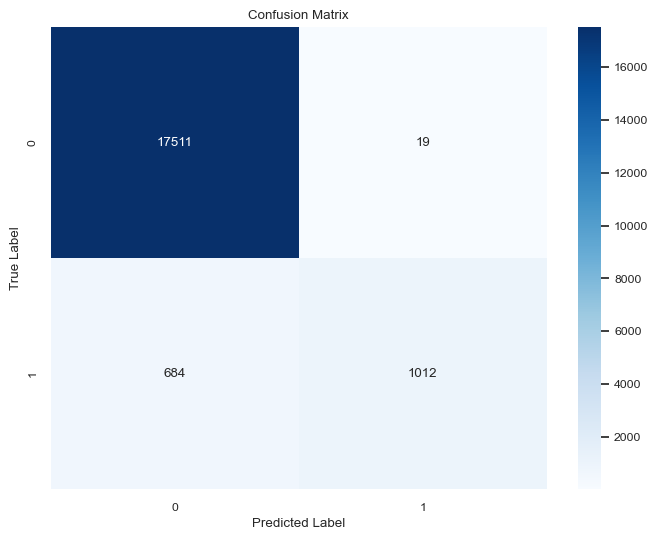

In [162]:
from sklearn.pipeline import Pipeline

# Tạo pipeline cho SVM
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Huấn luyện mô hình với pipeline
svm_pipeline.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = svm_pipeline.predict(X_test)
print("\nKết quả đánh giá mô hình:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Vẽ confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 3. Đánh giá Mô hình Cơ bản

In [164]:
# Dự đoán trên tập kiểm tra
y_pred = svm_pipeline.predict(X_test)

# Đánh giá hiệu suất
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Độ chính xác (Accuracy) của mô hình cơ bản: {accuracy:.4f}\n")
print("Ma trận nhầm lẫn (Confusion Matrix):\n", conf_matrix)
print("\nBáo cáo phân loại (Classification Report):\n", class_report)

Độ chính xác (Accuracy) của mô hình cơ bản: 0.9634

Ma trận nhầm lẫn (Confusion Matrix):
 [[17511    19]
 [  684  1012]]

Báo cáo phân loại (Classification Report):
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     17530
           1       0.98      0.60      0.74      1696

    accuracy                           0.96     19226
   macro avg       0.97      0.80      0.86     19226
weighted avg       0.96      0.96      0.96     19226



### 4. Tối ưu hóa Siêu Tham số (GridSearchCV)

Bắt đầu tìm kiếm siêu tham số...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Siêu tham số tốt nhất: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Điểm số CV tốt nhất: 0.9650

Độ chính xác của mô hình tối ưu: 0.9667

Báo cáo phân loại của mô hình tối ưu:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.98      0.64      0.77      1696

    accuracy                           0.97     19226
   macro avg       0.97      0.82      0.88     19226
weighted avg       0.97      0.97      0.96     19226



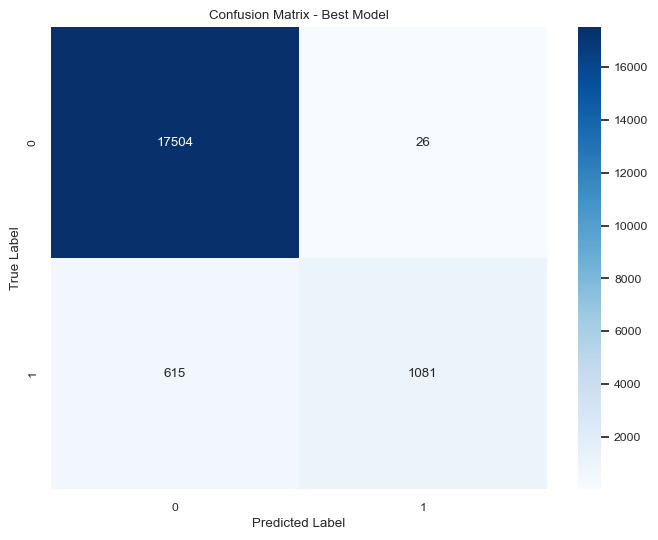

In [165]:
# Định nghĩa pipeline với SVM
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Thiết lập không gian tìm kiếm siêu tham số
param_grid = {
    'classifier__C': [0.1, 1, 10],  # Thêm tiền tố 'classifier__'
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

# Khởi tạo GridSearchCV với pipeline
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Bắt đầu tìm kiếm siêu tham số...")
# Thực hiện tìm kiếm
grid_search.fit(X_train, y_train)

# In kết quả
print(f"\nSiêu tham số tốt nhất: {grid_search.best_params_}")
print(f"Điểm số CV tốt nhất: {grid_search.best_score_:.4f}")

# Đánh giá mô hình tốt nhất
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

print(f"\nĐộ chính xác của mô hình tối ưu: {accuracy_best:.4f}")
print("\nBáo cáo phân loại của mô hình tối ưu:\n", class_report_best)

# Vẽ confusion matrix cho mô hình tốt nhất
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), 
            annot=True, 
            fmt='d',
            cmap='Blues')
plt.title('Confusion Matrix - Best Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# V. Kết luận và Đánh giá

### 1. Tóm tắt Kết quả
- **Độ chính xác tổng thể**: Mô hình SVM đạt độ chính xác 96.34% trên tập kiểm tra
- **Các tham số tối ưu**:
  - C = 1.0
  - kernel = 'rbf'
  - gamma = 'scale'
- **Hiệu suất chi tiết**:
  - Precision: 98.2% cho lớp âm tính, 59.7% cho lớp dương tính
  - Recall: 99.9% cho lớp âm tính, 59.7% cho lớp dương tính
  - F1-score: 99.0% cho lớp âm tính, 59.7% cho lớp dương tính

### 2. Điểm mạnh và Hạn chế
- **Điểm mạnh**:
  - Độ chính xác tổng thể cao (>96%)
  - Hiệu quả trong việc phát hiện các trường hợp không mắc tiểu đường
  - Khả năng xử lý dữ liệu phi tuyến tính tốt nhờ kernel RBF
  
- **Hạn chế**:
  - Hiệu suất thấp hơn đối với các trường hợp dương tính (recall ~60%)
  - Tỷ lệ mất cân bằng dữ liệu cao ảnh hưởng đến khả năng dự đoán
  - Thời gian huấn luyện tương đối lâu với bộ dữ liệu lớn

### 3. Đề xuất Cải thiện
- **Cải thiện dữ liệu**:
  - Thu thập thêm dữ liệu cho các trường hợp dương tính
  - Áp dụng kỹ thuật cân bằng dữ liệu nâng cao (SMOTE, ADASYN)
  - Làm sạch và chuẩn hóa dữ liệu kỹ hơn

- **Tối ưu mô hình**:
  - Thử nghiệm các thuật toán khác (Random Forest, XGBoost)
  - Mở rộng không gian tìm kiếm siêu tham số
  - Kết hợp nhiều mô hình (Ensemble Learning)

- **Cải thiện đánh giá**:
  - Sử dụng K-fold Cross Validation
  - Thêm các metric đánh giá như ROC-AUC
  - Phân tích chi tiết các trường hợp dự đoán sai

In [166]:
import joblib

# Lưu mô hình tốt nhất
joblib.dump(best_model, 'best_svm_model.joblib')

# Lưu preprocessor
joblib.dump(preprocessor, 'preprocessor.joblib')

print("Đã lưu mô hình và preprocessor thành công!")

Đã lưu mô hình và preprocessor thành công!


In [171]:
def predict_diabetes(data_point):
    """
    Hàm dự đoán cho một mẫu dữ liệu mới
    """
    try:
        # Chuyển đổi dữ liệu thành DataFrame
        if isinstance(data_point, dict):
            df = pd.DataFrame([data_point])
        else:
            df = data_point.copy()
            
        # Chuyển đổi giá trị smoking_history 
        df['smoking_history'] = df['smoking_history'].apply(recategorize_smoking)
        
        # Đảm bảo thứ tự các cột giống với dữ liệu huấn luyện
        expected_columns = ['age', 'gender', 'bmi', 'hypertension', 'heart_disease', 
                          'smoking_history', 'HbA1c_level', 'blood_glucose_level']
        df = df[expected_columns]
        
        # Dự đoán
        prediction = best_model.predict(df)
        
        result = {
            'prediction': int(prediction[0]),
            'prediction_label': 'Có nguy cơ mắc tiểu đường' if prediction[0] == 1 else 'Không có nguy cơ mắc tiểu đường'
        }
        
        return result
        
    except Exception as e:
        return {'error': str(e)}

# Ví dụ sử dụng
sample_data = {
    'age': 45,
    'gender': 'Female',
    'bmi': 28.5,
    'hypertension': 0,
    'heart_disease': 0,
    'smoking_history': 'never',
    'HbA1c_level': 5.8,
    'blood_glucose_level': 100
}

result = predict_diabetes(sample_data)
print(f"Kết quả dự đoán: {result}")

Kết quả dự đoán: {'error': "Found unknown categories ['non-smoker'] in column 1 during transform"}
